
# Exploratory Data Analysis (EDA) — application_train.csv






# 1 ) **Introduction**






## 1.1 AI-Based Loan Recovery Probability Prediction

### Dataset
Home Credit Default Risk

### Goal
To understand borrower behavior,
financial patterns,
missing values,
risk indicators,
and repayment characteristics
before building machine learning models
for loan recovery probability prediction.

## 1.2 Dataset Feature Description




| Column Name | Meaning |
|---|---|
| TARGET | Loan repayment status (0 = Repaid, 1 = Default) |
| AMT_CREDIT | Total loan amount given to applicant |
| AMT_INCOME_TOTAL | Total annual income of applicant |
| AMT_ANNUITY | Loan installment (EMI) amount |
| AMT_GOODS_PRICE | Price of goods for which loan was taken |
| DAYS_BIRTH | Applicant age in negative days |
| DAYS_EMPLOYED | Employment duration in days |
| EXT_SOURCE_1 | External credit score from source 1 |
| EXT_SOURCE_2 | External credit score from source 2 |
| EXT_SOURCE_3 | External credit score from source 3 |
| NAME_CONTRACT_TYPE | Type of loan contract |
| NAME_INCOME_TYPE | Source of applicant income |
| NAME_EDUCATION_TYPE | Education qualification |
| NAME_FAMILY_STATUS | Marital/family status |
| NAME_HOUSING_TYPE | Housing condition of applicant |
| OCCUPATION_TYPE | Occupation category |
| ORGANIZATION_TYPE | Employer organization type |
| CODE_GENDER | Gender of applicant |
| FLAG_OWN_CAR | Whether applicant owns a car |
| FLAG_OWN_REALTY | Whether applicant owns property/house |
| REGION_RATING_CLIENT | Region risk rating assigned to applicant |
| DEF_30_CNT_SOCIAL_CIRCLE | Number of defaults in applicant social circle |
| DAYS_LAST_PHONE_CHANGE | Days since last phone number change |
| DAYS_ID_PUBLISH | Days since ID information update |
| REG_CITY_NOT_WORK_CITY | Whether work city differs from registration city |
| REG_CITY_NOT_LIVE_CITY | Whether living city differs from registration city |





## 1.3 Engineered Feature Description




| Engineered Feature | Meaning |
|---|---|
| AGE_YEARS | Applicant age converted into years |
| EMPLOYMENT_YEARS | Employment duration converted into years |
| EXT_SOURCE_MEAN | Average of all external credit scores |
| CREDIT_INCOME_RATIO | Loan amount relative to applicant income |
| ANNUITY_INCOME_RATIO | EMI burden relative to applicant income |
| HAS_COLLATERAL | Whether applicant owns car/property |
| AGE_GROUP | Applicant age category |
| DAYS_EMPLOYED_ANOMALY | Flag for anomalous employment value (365243) |


# 2 )  **Data Understanding**

## 2.1  Library import

In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly
import plotly.graph_objects as go
import plotly.offline as py
import plotly.io as pio

# Seaborn style
sns.set_style("whitegrid")

# Plotly renderer
pio.renderers.default = "colab"

# Enable plotly notebook mode
py.init_notebook_mode(connected=True)

# Display plots inline
%matplotlib inline

# Install cufflinks

!pip install cufflinks

# cufflinks import

import plotly.io as pio
pio.renderers.default = "colab"

import cufflinks as cf

cf.go_offline()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.9 MB/s eta 0:00:00



## 2.2 Load Dataset



In [ ]:
# Load dataset

application_train = pd.read_csv("application_train.csv")

# Display first 5 rows

application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0





- The dataset contains a mixture of numerical
and categorical features,
including loan amount,
income information,
credit history,
and demographic attributes.




## 2.3 Basic Data Information



In [ ]:
# Basic dataset information

application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB





- The dataset contains 307,511 borrower records
with 122 features related to demographic,financial,credit,and repayment behavior information.

- The dataset consists of both numerical and categorical variables,including 65 float features,41 integer features,
and 16 object-type categorical features.

- The overall memory usage is approximately 286 MB,
indicating a moderately large real-world financial dataset
suitable for machine learning and risk analysis.



In [ ]:
# Shape of dataset

print("Dataset Shape :",application_train.shape)

# Rows and columns separately

print("Number of Rows :",application_train.shape[0])

print("Number of Columns :",application_train.shape[1])

Dataset Shape : (307511, 122)
Number of Rows : 307511
Number of Columns : 122



## 2.4 Statistical Summary of Numerical Features



In [ ]:
# Statistical summary of numerical features

application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000





* The dataset contains multiple financial and demographic features.

* Most applicants belong to the non-default category,
  indicating class imbalance in the target variable.

* Features such as AMT_INCOME_TOTAL,
  AMT_CREDIT,
  and AMT_ANNUITY contain wide value ranges,
  suggesting the presence of outliers.

* The DAYS_EMPLOYED feature contains an unrealistic maximum value of 365243,
  indicating anomaly values in the dataset.

* Several numerical variables exhibit high variability,
  which may influence model performance.







# 3 ) **Missing Value Analysis**


## 3.1 Missing Value Analysis



In [ ]:
#Checking missing values
application_train.isnull().sum().head(50)


,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,12




- Multiple features contain missing values in the dataset.

- Features such as OWN_CAR_AGE,
  OCCUPATION_TYPE,
  and EXT_SOURCE_1 contain a high number of missing records.

- Housing-related features,
  including APARTMENTS_AVG,
  BASEMENTAREA_AVG,
  and COMMONAREA_AVG,
  also show significant missing values.

- Missing values are not uniformly distributed across features,
  indicating the need for feature-wise preprocessing strategies.

- Some missing values may represent unavailable customer information
  rather than data collection errors.




## 3.2 Missing Value Percentage Analysis



In [ ]:
# Calculate percentage of missing values
missing_percent = (application_train.isnull().mean() * 100).sort_values(ascending=False)

# Display top 50 features
missing_percent.head(50)

,0
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953




- Several housing-related features contain extremely high missing percentages,
  with many columns having more than 60% missing values.

- Features such as COMMONAREA_AVG,
  NONLIVINGAPARTMENTS_AVG,
  and LIVINGAPARTMENTS_AVG show the highest missing percentages.

- The OWN_CAR_AGE feature contains over 65% missing values,
  likely because many applicants do not own a car.

- EXT_SOURCE_1 also contains substantial missing data,
  which may require special preprocessing due to its importance in credit risk prediction.

- OCCUPATION_TYPE contains nearly 30% missing values,
  indicating incomplete employment-related information for many applicants.

- The large amount of missing data suggests that feature-wise missing value handling
  will be necessary during the data cleaning phase.




## 3.3 Missing Value Ratio Analysis



In [ ]:
# Total missing values

total = application_train.isnull().sum()

# Missing value percentage

percent = (application_train.isnull().sum()/len(application_train)) * 100

# Combine total and percentage

missing_df = pd.concat([total, percent],axis=1,keys=['Total Missing','Missing Ratio (%)'])

# Sort by highest missing ratio

missing_df = missing_df.sort_values(by='Missing Ratio (%)', ascending=False)

# Display top 50

missing_df.head(50)

,Total Missing,Missing Ratio (%)
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


- Housing-related features and EXT_SOURCE_1 contain extremely high missing values, with several variables exceeding 50% missing ratio.


## 3.4 Missing Value Visualization



In [ ]:
# Missing value percentage

missing_percent = (application_train.isnull().mean() * 100).sort_values(ascending=False)

# Top missing columns

top_missing = missing_percent.head(50)

# Color coding

colors = []

for val in top_missing:

    if val > 50:
        colors.append('red')

    elif val >= 20:
        colors.append('orange')

    else:
        colors.append('green')

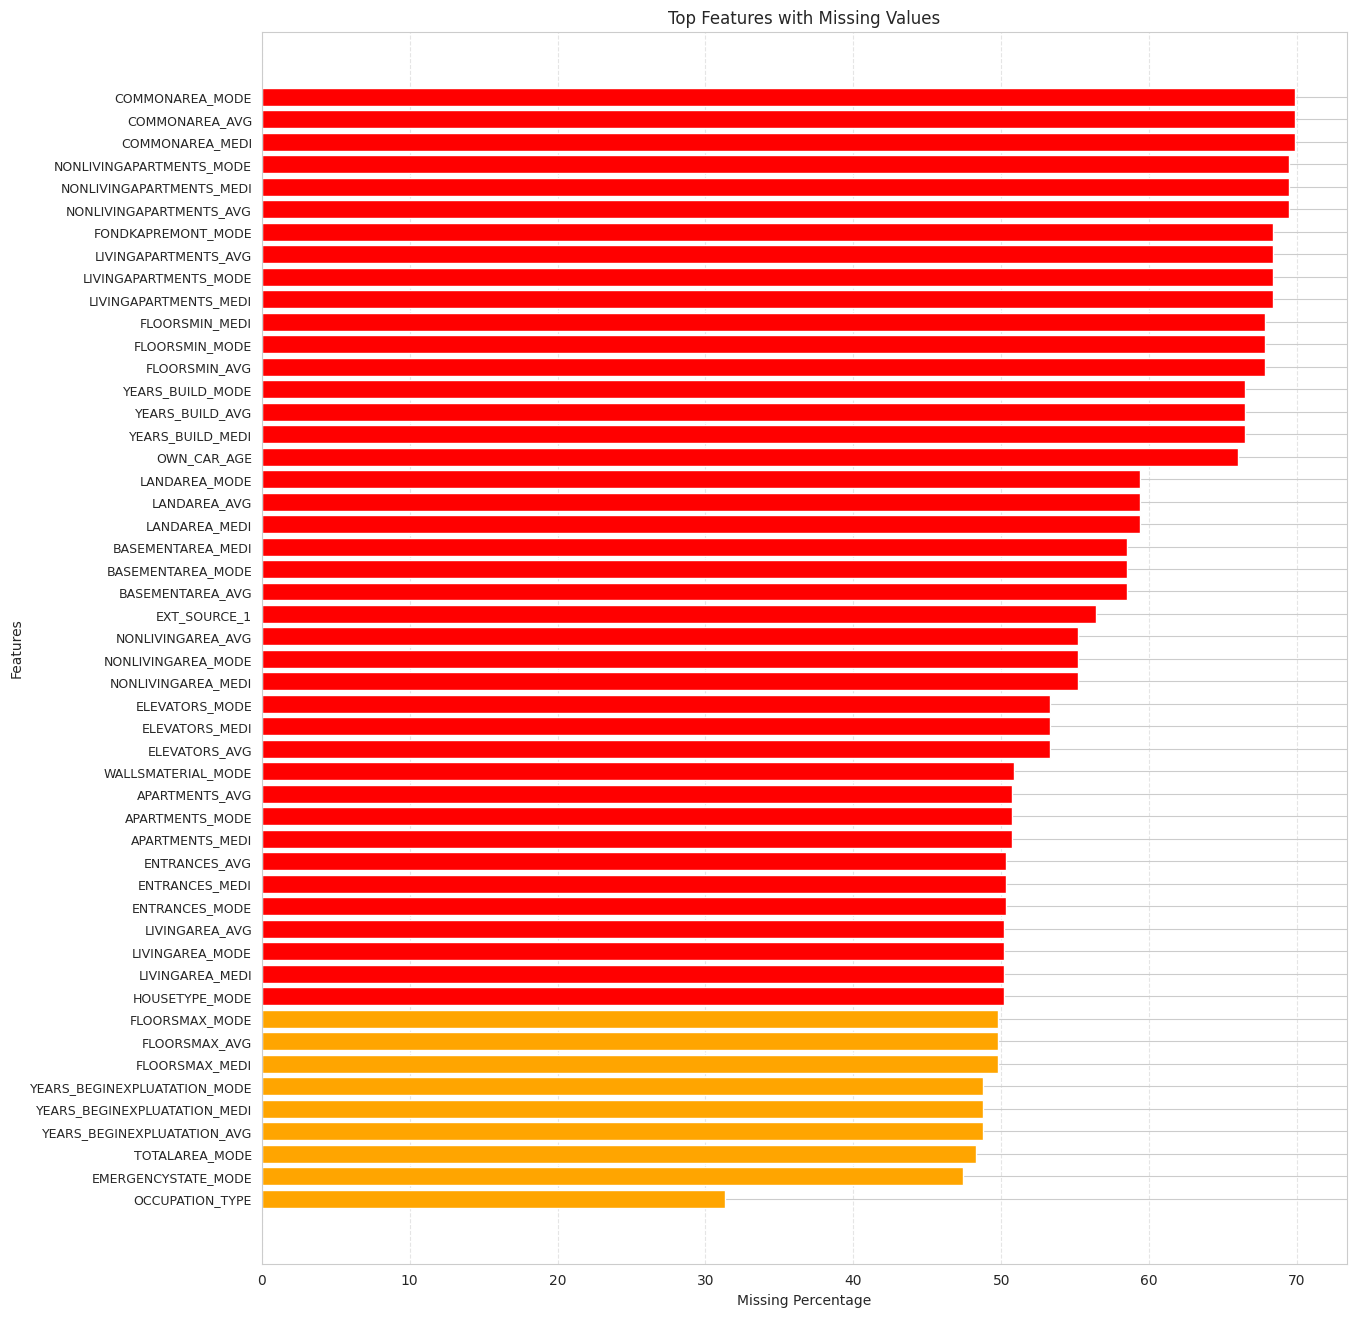

In [ ]:
# Missing value
plt.figure(figsize=(14,16))
plt.barh(top_missing.index,top_missing.values,color=colors)
plt.xlabel('Missing Percentage')
plt.ylabel('Features')
plt.title('Top Features with Missing Values')
plt.yticks(fontsize=9)
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.gca().invert_yaxis()
plt.show()




- Most housing-related features contain extremely high missing values (>50%),
  indicating major preprocessing requirements before model building.


# 4 )  **Target Variable Analysis**


## 4.1 Target Variable Distribution



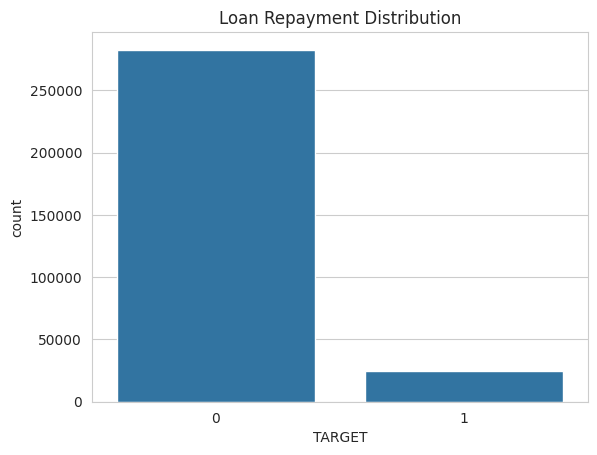

In [ ]:
# target varible  distibution plote
sns.countplot(x='TARGET',data=application_train)
plt.title("Loan Repayment Distribution")
plt.show()

- The dataset is highly imbalanced, with a significantly larger number of non-default applicants (TARGET = 0) compared to default-risk applicants (TARGET = 1).
 - Approximately 92% of applicants did not experience repayment difficulties, while only a small percentage showed payment risk behavior

##4.2 Class imbalance analysis

In [ ]:
# Class imbalance analysis

target_counts = application_train['TARGET'].value_counts()

print('Repaid Loans (0):',target_counts[0])
print('Default Loans (1):',target_counts[1])
print('Class Ratio:',round(target_counts[0] / target_counts[1], 2),': 1')

Repaid Loans (0): 282686
Default Loans (1): 24825
Class Ratio: 11.39 : 1


 # 5 )  **EXT_SOURCE Statistical Analysis**

## 5.1 EXT_SOURCE Statistics

In [ ]:
# Important EXT_SOURCE features

ext_cols = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
print('=== EXT_SOURCE STATS BY TARGET ===')

# Statistical comparison

for col in ext_cols:
  print(f'\n{col}:')
  stats = application_train.groupby('TARGET')[col].agg(['mean', 'median', 'std'])
  stats.index = ['Recovered','Not Recovered']
  print(stats.round(3))
  print(f'Missing: {application_train[col].isnull().mean()*100:.1f}%')

=== EXT_SOURCE STATS BY TARGET ===

EXT_SOURCE_1:
                mean  median    std
Recovered      0.511   0.517  0.209
Not Recovered  0.387   0.362  0.205
Missing: 56.4%

EXT_SOURCE_2:
                mean  median    std
Recovered      0.523   0.574  0.186
Not Recovered  0.411   0.440  0.213
Missing: 0.2%

EXT_SOURCE_3:
                mean  median    std
Recovered      0.521   0.546  0.190
Not Recovered  0.391   0.379  0.206
Missing: 19.8%




- Recovered applicants consistently show higher EXT_SOURCE scores,
  indicating lower repayment risk and stronger credit profiles.



## 5.2 EXT_SOURCE Distribution

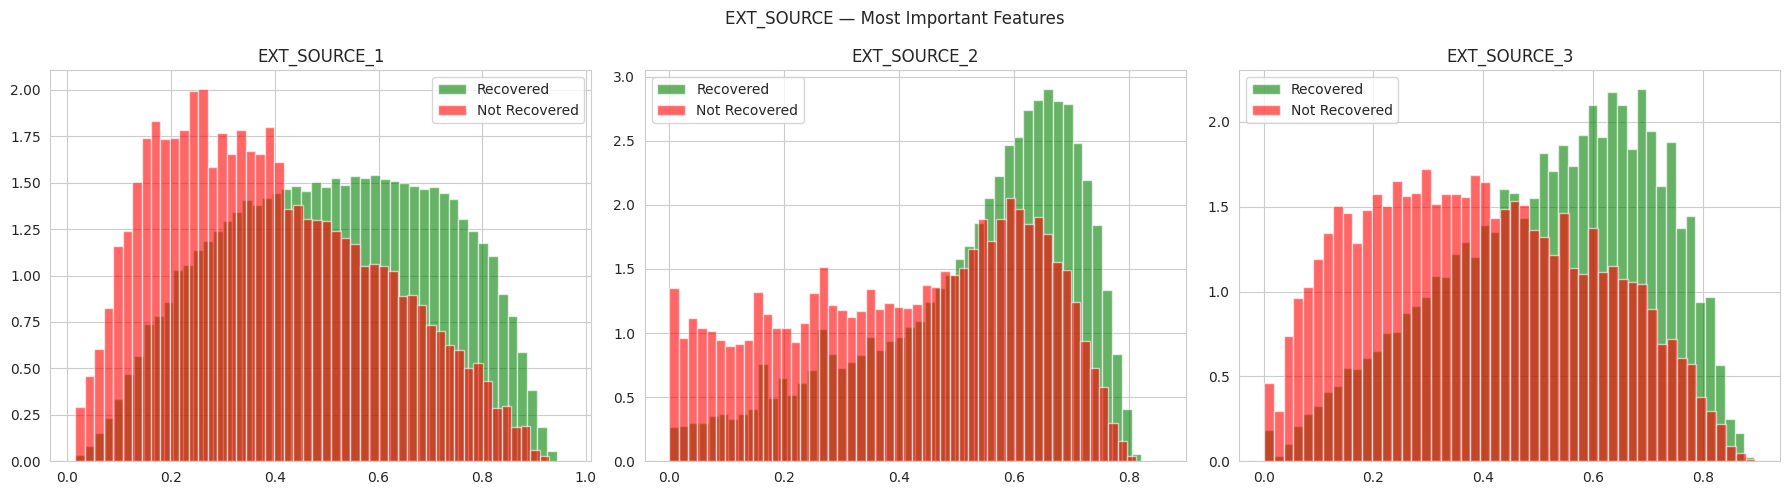

In [ ]:
ext_cols = ['EXT_SOURCE_1',
            'EXT_SOURCE_2',
            'EXT_SOURCE_3']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(ext_cols):
    ax = axes[i]
    for target, color, label in zip(
        [0, 1],
        ['green', 'red'],
        ['Recovered', 'Not Recovered']
        ):
      data = application_train[application_train['TARGET']==target][col].dropna()
      ax.hist(data, bins=50, alpha=0.6,color=color, label=label,density=True)
      ax.set_title(f'{col}')
      ax.legend()

plt.suptitle('EXT_SOURCE — Most Important Features')
plt.tight_layout()
plt.show()



- Recovered applicants consistently exhibit higher EXT_SOURCE values,
  while non-recovered applicants are concentrated at lower score ranges,
  confirming EXT_SOURCE features as strong repayment risk indicators.



## 5.3 EXT_SOURCE Combined Mean

EXT_SOURCE_MEAN ROC-AUC: 0.717
Single feature provides strong predictive performance.


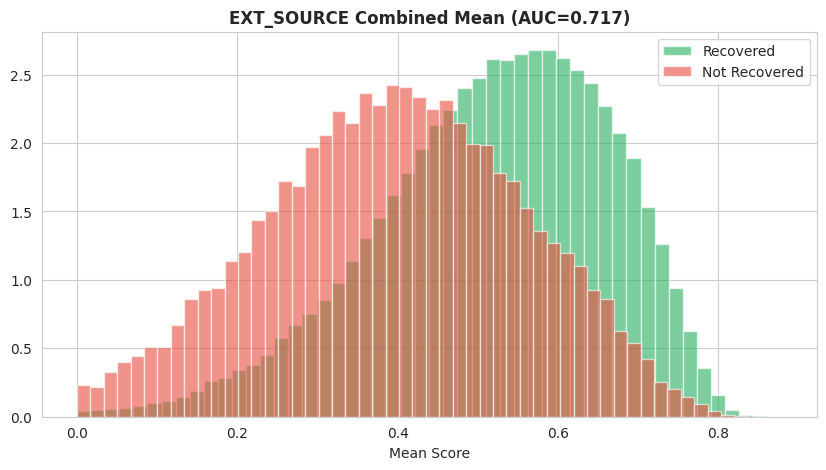

In [ ]:
# Create combined EXT_SOURCE feature
from sklearn.metrics import roc_auc_score

application_train['EXT_SOURCE_MEAN'] = application_train[ext_cols].mean(axis=1)

# Remove missing values

valid = application_train[['EXT_SOURCE_MEAN', 'TARGET']].dropna()

# Calculate ROC-AUC score

auc = roc_auc_score(valid['TARGET'] ,-valid['EXT_SOURCE_MEAN'])

# Display result

print(f'EXT_SOURCE_MEAN ROC-AUC: {auc:.3f}')
print('Single feature provides strong predictive performance.')

# Visualization

plt.figure(figsize=(10,5))

for target, color, label in zip([0, 1],['#27AE60', '#E74C3C'],['Recovered', 'Not Recovered']):
  data = application_train[application_train['TARGET'] == target]['EXT_SOURCE_MEAN'].dropna()
  plt.hist(data ,bins=50 ,alpha=0.6 ,density=True ,color=color ,label=label)

plt.title(f'EXT_SOURCE Combined Mean (AUC={auc:.3f})',fontweight='bold')
plt.xlabel('Mean Score')
plt.legend()
plt.show()



- The combined EXT_SOURCE_MEAN feature achieves a strong ROC-AUC score of 0.717,
  demonstrating high predictive power for repayment risk classification.

- Applicants with higher EXT_SOURCE_MEAN values
  show significantly better recovery behavior,
  confirming external credit scores as the strongest risk indicators in the dataset.




# 6 ) **Financial Feature Distribution Analysis**



##  6.1 Financial Feature Distributions

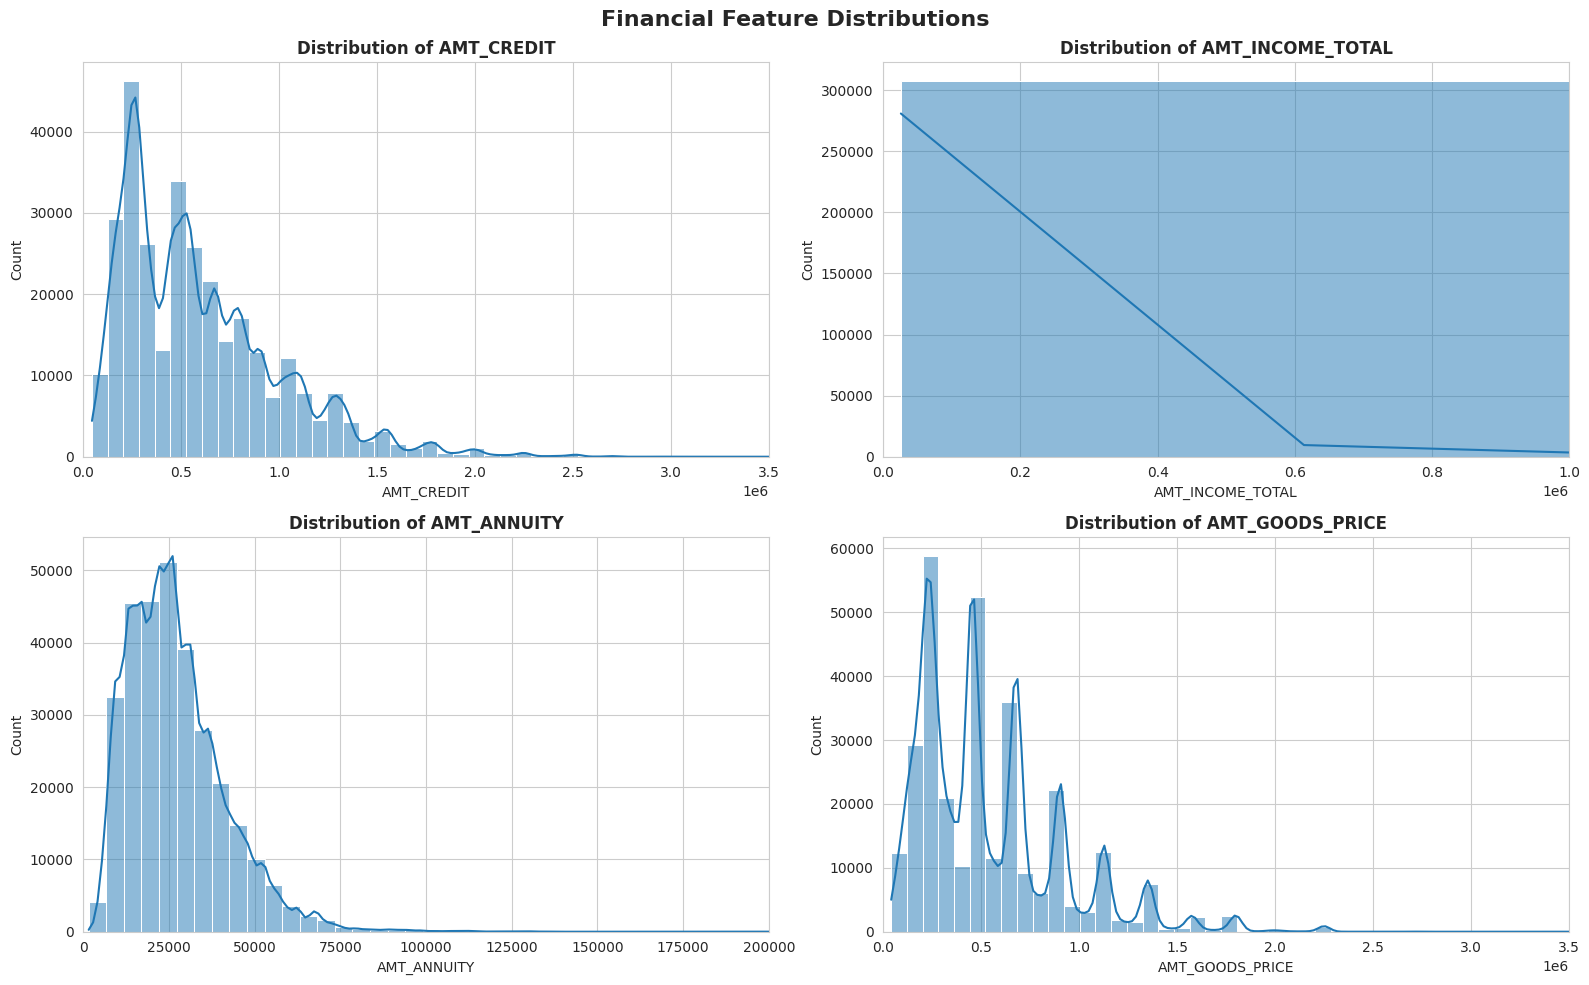

In [ ]:

# Financial feature distributions

financial_cols = ['AMT_CREDIT' ,'AMT_INCOME_TOTAL' ,'AMT_ANNUITY' ,'AMT_GOODS_PRICE']

# Create subplots

fig, axes = plt.subplots(2 ,2 ,figsize=(16,10))
axes = axes.flatten()

# Plot distributions

for ax, col in zip(axes, financial_cols):
  sns.histplot(application_train[col].dropna() ,bins=50 ,kde=True ,ax=ax)
  ax.set_title(f'Distribution of {col}' ,fontweight='bold')

# Custom x-limits

axes[0].set_xlim(0, 3500000)
axes[1].set_xlim(0, 1000000)
axes[2].set_xlim(0, 200000)
axes[3].set_xlim(0, 3500000)

# Main title

plt.suptitle('Financial Feature Distributions' ,fontsize=16 ,fontweight='bold')
plt.tight_layout()
plt.show()



- Financial features exhibit positively skewed distributions,
  with most applicants concentrated in lower-to-medium financial ranges.

- AMT_CREDIT and AMT_GOODS_PRICE show similar patterns,
  indicating a strong relationship between loan amount and purchased goods value.




## 6.2 Ratio Feature Analysis



In [ ]:
# Create engineered ratio features
application_train['CREDIT_INCOME_RATIO'] = (application_train['AMT_CREDIT']/application_train['AMT_INCOME_TOTAL'])
application_train['ANNUITY_INCOME_RATIO'] = (application_train['AMT_ANNUITY']/application_train['AMT_INCOME_TOTAL'])
# Preview engineered features
application_train[['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO']].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,307499.000000
mean,3.957570,0.180930
std,2.689728,0.094574
min,0.004808,0.000224
25%,2.018667,0.114782
50%,3.265067,0.162833
75%,5.159880,0.229067
max,84.736842,1.875965



- The average loan amount is nearly 4× the applicant’s income,
  indicating substantial borrowing relative to earnings.

- Higher credit-to-income and annuity-to-income ratios
  may indicate increased financial burden and repayment risk.



# 7 ) **Categorical Feature Analysis**


## 7.1 Loan Type Distribution by TARGET



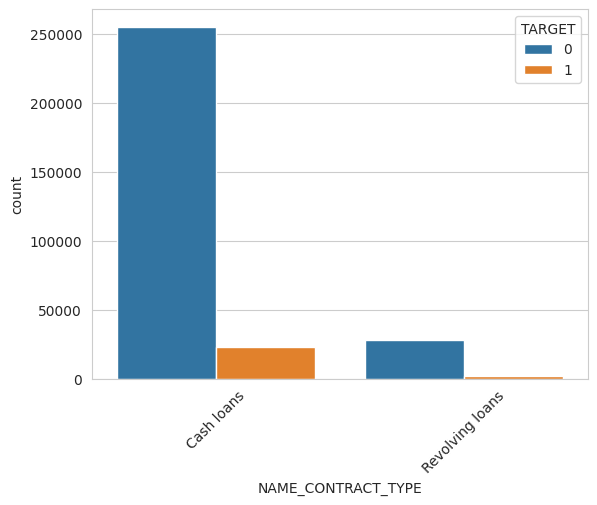

In [ ]:
sns.countplot(x='NAME_CONTRACT_TYPE' ,hue='TARGET',data=application_train)
plt.xticks(rotation=45)
plt.show()



- Cash loans represent the majority of loan applications in the dataset.

- Revolving loans exhibit comparatively lower default counts,
  suggesting relatively better repayment behavior than cash loans.



## 7.2 Asset Ownership Distribution



In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"

# Value counts
temp1 = application_train["FLAG_OWN_CAR"].value_counts()
temp2 = application_train["FLAG_OWN_REALTY"].value_counts()

# Figure
fig = {
    "data": [
    # Own Car Donut
     {
            "values": temp1.values,
            "labels": temp1.index,
            "domain": {"x": [0, .48]},
            "name": "Own Car",
            "hoverinfo": "label+percent+name",
            "hole": .6,
            "type": "pie",
            "marker": {"colors": ["#1F77B4", "#2CA02C"]}
        },

        # Own Realty Donut
        {
            "values": temp2.values,
            "labels": temp2.index,
            "domain": {"x": [.52, 1]},
            "name": "Own Realty",
            "hoverinfo": "label+percent+name",
            "hole": .6,
            "type": "pie",
            "marker": {"colors": ["#1F77B4", "#2CA02C"]}
        }
    ],
    "layout": {
        "title": "Asset Ownership Distribution",
        "annotations": [{
                "font": {"size": 20},
                "showarrow": False,
                "text": "Own Car",
                "x": 0.20,
                "y": 0.5
                },
              {
                "font": {"size": 20},
                "showarrow": False,
                "text": "Own Realty",
                "x": 0.80,
                "y": 0.5
            }
        ]
    }
}

# Show chart
go.Figure(fig).show()




- A majority of applicants do not own cars,
  while real estate ownership is comparatively higher among borrowers.

- Asset ownership may indicate greater financial stability
  and potentially lower repayment risk.




## 7.3 Income Source Distribution



In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"
temp = application_train["NAME_INCOME_TYPE"].value_counts()

income_df = pd.DataFrame({'labels': temp.index,'values': temp.values})

income_df.iplot(kind='pie',labels='labels',values='values',title="Income sources of Applicant's",hole=0.5,
                # Small slices slightly outside
                pull=[0,0,0,0,0.1,0.1,0.1,0.1],
                # Finance style colors
                colors=[
                  "#1F77B4",
                  "#2CA02C",
                  "#FF7F0E",
                  "#9467BD",
                  "#8C564B",
                  "#E377C2",
                  "#7F7F7F",
                  "#BCBD22"],
                # Show percentage + label
                textinfo='percent+label')



- Salaried working professionals constitute the majority of loan applicants,
  followed by commercial associates and pensioners.

- Stable income sources are dominant in the dataset,
  suggesting income type plays an important role in repayment behavior.




## 7.4 Family Status Distribution



In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"
temp = application_train["NAME_FAMILY_STATUS"].value_counts()
df = pd.DataFrame({'labels': temp.index ,'values': temp.values})
df.iplot(kind='pie',labels='labels',values='values', title='Family Status of Applicant\'s', hole = 0.5)



- Married applicants constitute the majority of borrowers in the dataset,
  followed by single and civil marriage applicants.

- Family status may influence financial stability
  and repayment behavior patterns.



### 7.4.1 Family Status vs Loan Repayment

In [ ]:
from plotly.offline import iplot
temp = application_train["NAME_FAMILY_STATUS"].value_counts()
#print(temp.values)
temp_y0 = []
temp_y1 = []
for val in temp.index:
    temp_y1.append(np.sum(application_train["TARGET"][application_train["NAME_FAMILY_STATUS"]==val] == 1))
    temp_y0.append(np.sum(application_train["TARGET"][application_train["NAME_FAMILY_STATUS"]==val] == 0))
trace1 = go.Bar(x = temp.index ,y = (temp_y1 / temp.sum()) * 100,name='YES')
trace2 = go.Bar(x = temp.index ,y = (temp_y0 / temp.sum()) * 100,name='NO')

data = [trace1, trace2]
layout = go.Layout(title = "Family Status of Applicant's in terms of loan is repayed or not in %",
    #barmode='stack',
    width = 1000,
    xaxis=dict(title='Family Status',tickfont=dict(size=14,color='rgb(107, 107, 107)')),
    yaxis=dict(title='Count in %',titlefont=dict(size=16,color='rgb(107, 107, 107)'),
    tickfont=dict(size=14,color='rgb(107, 107, 107)')))

fig = go.Figure(data=data, layout=layout)
iplot(fig)

- Married applicants account for the highest proportion of both recovered and non-recovered loans due to their dominant presence in the dataset.

- Widowed and civil marriage applicants exhibit comparatively lower default proportions,
  suggesting relatively stable repayment behavior.



## 7.5  Occupation Analysis


In [ ]:
temp = application_train["OCCUPATION_TYPE"].value_counts()
fig = go.Figure(data=[go.Bar(x=temp.index ,y=temp.values ,marker_color="#1F77B4")])

fig.update_layout(title="Occupation of Applicants who applied for loan" ,xaxis_title="Occupation" ,yaxis_title="Count")
fig.show()



- Laborers, sales staff, and core staff represent the largest occupational groups among loan applicants.

- Occupation type may significantly influence income stability
  and repayment capability.



## 7.6 Education Level Distribution


In [ ]:
temp = application_train["NAME_EDUCATION_TYPE"].value_counts()
df = pd.DataFrame({'labels': temp.index,'values': temp.values})
df.iplot(kind='pie',labels='labels',values='values', title='Education of Applicant\'s', hole = 0.5)


- Most loan applicants possess secondary or higher secondary education,
  while applicants with academic degrees form a very small proportion.

- Education level may influence income potential,
  employment stability,
  and repayment capability.




## 7.7 Housing Type Distribution



In [ ]:
temp = application_train["NAME_HOUSING_TYPE"].value_counts()
df = pd.DataFrame({'labels': temp.index,'values': temp.values})
df.iplot(kind='pie',labels='labels',values='values', title='Type of House', hole = 0.5)


- The majority of applicants live in houses or apartments,
  while other housing categories represent only a small fraction of borrowers.

- Housing type may reflect financial stability
  and overall socioeconomic condition of applicants.




## 7.8 Organization Type Distribution


In [ ]:
import plotly.graph_objects as go

temp = application_train["ORGANIZATION_TYPE"].value_counts().head(20)

fig = go.Figure(data=[go.Bar(x=temp.index,y=temp.values,marker_color="#1F77B4")])

fig.update_layout(title="Top Organizations of Applicants",
                  xaxis_title="Organization Type",
                  yaxis_title="Count")
fig.show()



- Business Entity Type 3,
  XNA,
  and Self-employed categories represent the largest organizational groups among applicants.

- Organization type may influence applicant income stability
  and repayment capability.



## 7.9 Gender Analysis






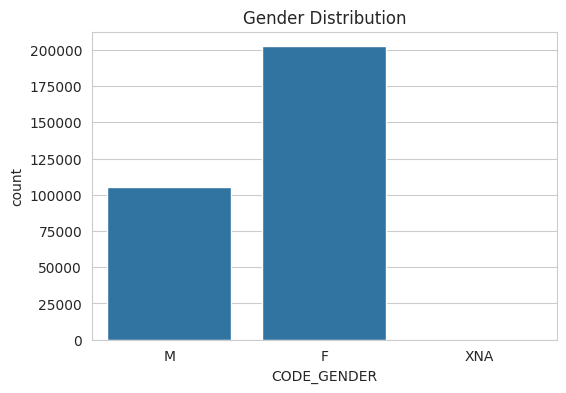

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='CODE_GENDER',data=application_train)
plt.title("Gender Distribution")
plt.show()



- Female applicants constitute the majority of borrowers in the dataset,
  significantly outnumbering male applicants.

- Gender distribution imbalance may influence repayment behavior
  and lending risk analysis.



 ### 7.9.1 Gender-wise Loan Repayment Distribution

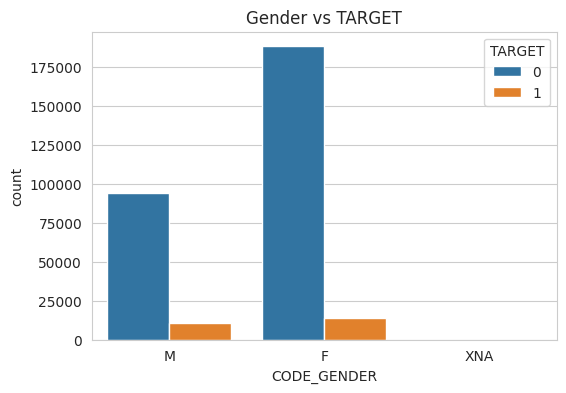

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='CODE_GENDER',hue='TARGET',data=application_train)
plt.title("Gender vs TARGET")
plt.show()


- Female applicants constitute the majority of both recovered and non-recovered borrowers in the dataset.

- Male applicants exhibit comparatively fewer loan applications,
  while the XNA category contains negligible records.


### 7.9.2 Gender-wise Default Rate Analysis

In [ ]:
gender_analysis = (application_train.groupby('CODE_GENDER').agg(Total_Applicants = ('TARGET','count'),Default_Rate = ('TARGET','mean')))

# Convert to percentage
gender_analysis['Default_Rate'] = (gender_analysis['Default_Rate'] * 100)

gender_analysis



,Total_Applicants,Default_Rate
CODE_GENDER,,
F,202448,6.999328
M,105059,10.141920
XNA,4,0.000000



- Male applicants exhibit a higher default rate (10.1%)
  compared to female applicants (7.0%).

- Female borrowers demonstrate relatively better repayment behavior,
  despite representing the majority of applicants in the dataset.

## 7.10 Failure to Repay by Age Group

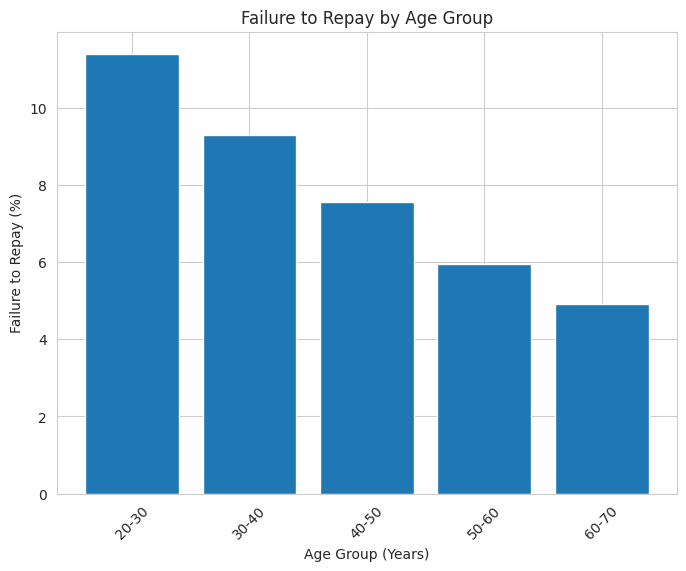

In [ ]:
# Create age in years
application_train['AGE_YEARS'] = (application_train['DAYS_BIRTH'] / -365).astype(int)

# Create age bins
application_train['AGE_GROUP'] = pd.cut(application_train['AGE_YEARS'],
                                        bins=[20, 30, 40, 50, 60, 70],
                                        labels=[
                                          '20-30',
                                          '30-40',
                                          '40-50',
                                          '50-60',
                                          '60-70'])
# Calculate default rate
age_groups = (application_train.groupby('AGE_GROUP',observed=True)['TARGET'].mean())

# Plot
plt.figure(figsize=(8,6))

plt.bar(age_groups.index.astype(str),100 * age_groups.values,color='#1F77B4')

# Labels

plt.xticks(rotation=45)
plt.xlabel("Age Group (Years)")
plt.ylabel("Failure to Repay (%)")
plt.title("Failure to Repay by Age Group")
plt.show()

- Younger applicants exhibit the highest default rates,
  while repayment performance steadily improves with increasing age.

- Older borrowers demonstrate comparatively lower repayment risk
  and stronger financial stability.


# 8 ) **Anomaly and Outlier Analysis**


## 8.1 Anomaly Detection Analysis



In [ ]:
(application_train['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

In [ ]:

# Detect anomaly values in DAYS_EMPLOYED

anomaly_count = (application_train['DAYS_EMPLOYED'] == 365243).sum()

# Percentage of anomalies

anomaly_percent = (anomaly_count/len(application_train)) * 100

# Separate anomaly and normal records

anom_df = application_train[application_train['DAYS_EMPLOYED'] == 365243]

normal_df = application_train[application_train['DAYS_EMPLOYED'] != 365243]

# Display results

print(f'Anomaly Count : {anomaly_count:,}')
print(f'Anomaly Percentage : {anomaly_percent:.2f}%')
print()
print(f'Normal Default Rate : {normal_df["TARGET"].mean()*100:.2f}%')
print(f'Anomaly Default Rate : {anom_df["TARGET"].mean()*100:.2f}%')

Anomaly Count : 55,374
Anomaly Percentage : 18.01%

Normal Default Rate : 8.66%
Anomaly Default Rate : 5.40%



- Approximately 18% of records contain the anomalous value 365243 in DAYS_EMPLOYED,
  indicating a likely placeholder or data entry issue.

- Interestingly,
  anomaly records exhibit a lower default rate (5.40%)
  compared to normal applicants (8.66%),
  making anomaly flagging an important feature engineering step.


## 8.2  Anomaly vs Normal Default Rate

In [ ]:
# Separate anomaly and normal records

anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
normal = application_train[application_train['DAYS_EMPLOYED'] != 365243]

# Compare default rates

print("Anomaly Default Rate:",anom['TARGET'].mean())
print("Normal Default Rate:",normal['TARGET'].mean())

Anomaly Default Rate: 0.05399646043269404
Normal Default Rate: 0.0865997453765215


- Applicants with the anomalous DAYS_EMPLOYED value (365243)
  exhibit a lower default rate (~5.4%)
  compared to normal applicants (~8.7%).

- The anomaly likely represents a special placeholder value,
  making anomaly flagging and preprocessing important for model performance.


## 8.3 Outlier Detection Analysis

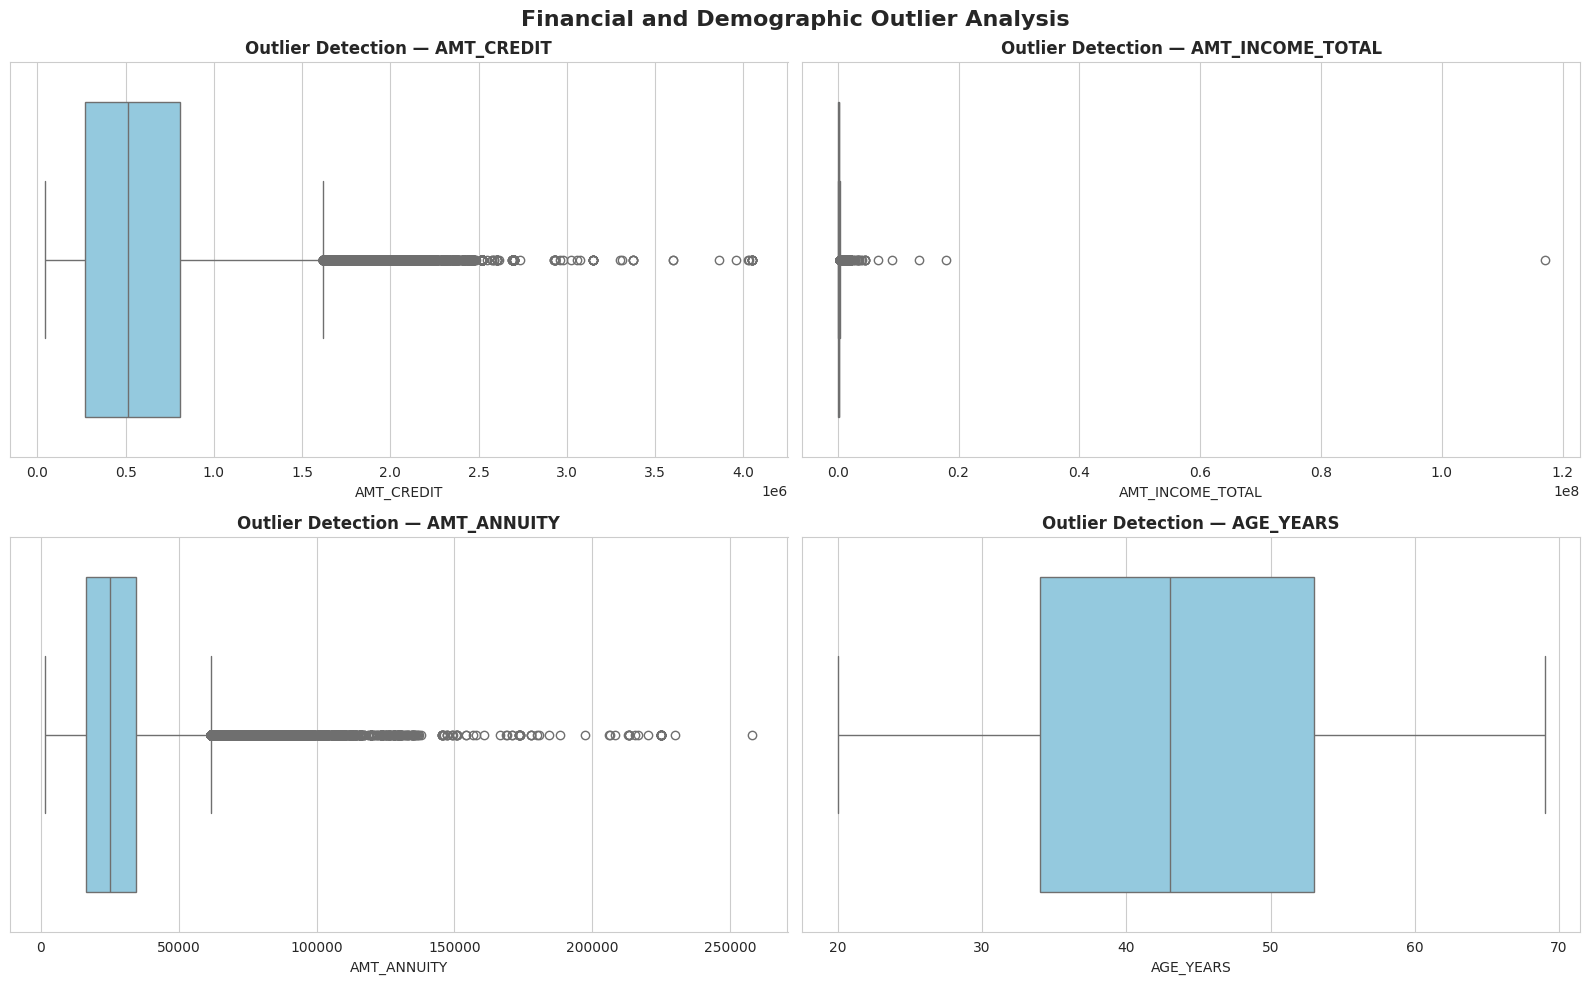

In [ ]:
# Create AGE_YEARS feature

application_train['AGE_YEARS'] = (application_train['DAYS_BIRTH'] / -365).astype(int)

# Important numerical features

outlier_cols = ['AMT_CREDIT','AMT_INCOME_TOTAL','AMT_ANNUITY','AGE_YEARS']

# Create subplots

fig, axes = plt.subplots(2,2,figsize=(16,10))
axes = axes.flatten()

# Boxplots

for ax, col in zip(axes, outlier_cols):
  sns.boxplot(x=application_train[col],ax=ax,color='skyblue')
  ax.set_title(f'Outlier Detection — {col}',fontweight='bold')

# Main title

plt.suptitle('Financial and Demographic Outlier Analysis' ,fontsize=16 ,fontweight='bold')
plt.tight_layout()
plt.show()


- Financial variables such as AMT_CREDIT,
  AMT_INCOME_TOTAL,
  and AMT_ANNUITY contain significant outliers,
  indicating the presence of high-value loan and income applicants.

- AGE distribution appears relatively stable with fewer extreme outliers,
  while financial features may require capping or transformation during preprocessing.

# 9 ) **Correlation and Risk Analysis**


##  9.1 Correlation Analysis with TARGET



In [ ]:
# Correlation with TARGET variable
corr_target = application_train.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values()

# Top negative correlations

print('=== TOP 10 NEGATIVE CORRELATIONS ===')
print(corr_target.head(10).round(3))
print()

# Top positive correlations

print('=== TOP 10 POSITIVE CORRELATIONS ===')
print(corr_target.tail(10).round(3))

=== TOP 10 NEGATIVE CORRELATIONS ===
EXT_SOURCE_MEAN   -0.222
EXT_SOURCE_3      -0.179
EXT_SOURCE_2      -0.160
EXT_SOURCE_1      -0.155
AGE_YEARS         -0.078
DAYS_EMPLOYED     -0.045
FLOORSMAX_AVG     -0.044
FLOORSMAX_MEDI    -0.044
FLOORSMAX_MODE    -0.043
AMT_GOODS_PRICE   -0.040
Name: TARGET, dtype: float64

=== TOP 10 POSITIVE CORRELATIONS ===
DAYS_REGISTRATION              0.042
FLAG_DOCUMENT_3                0.044
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_EMP_PHONE                 0.046
REG_CITY_NOT_WORK_CITY         0.051
DAYS_ID_PUBLISH                0.051
DAYS_LAST_PHONE_CHANGE         0.055
REGION_RATING_CLIENT           0.059
REGION_RATING_CLIENT_W_CITY    0.061
DAYS_BIRTH                     0.078
Name: TARGET, dtype: float64




- EXT_SOURCE_1,
  EXT_SOURCE_2,
  and EXT_SOURCE_3 exhibit the strongest negative correlations with TARGET,
  indicating that higher external credit scores are associated with lower default risk.

- Features such as REGION_RATING_CLIENT,
  DAYS_LAST_PHONE_CHANGE,
  and DAYS_ID_PUBLISH show positive correlation with default risk,
  suggesting weaker client profiles and financial instability.



## 9.2 Correlation Heatmap Analysis



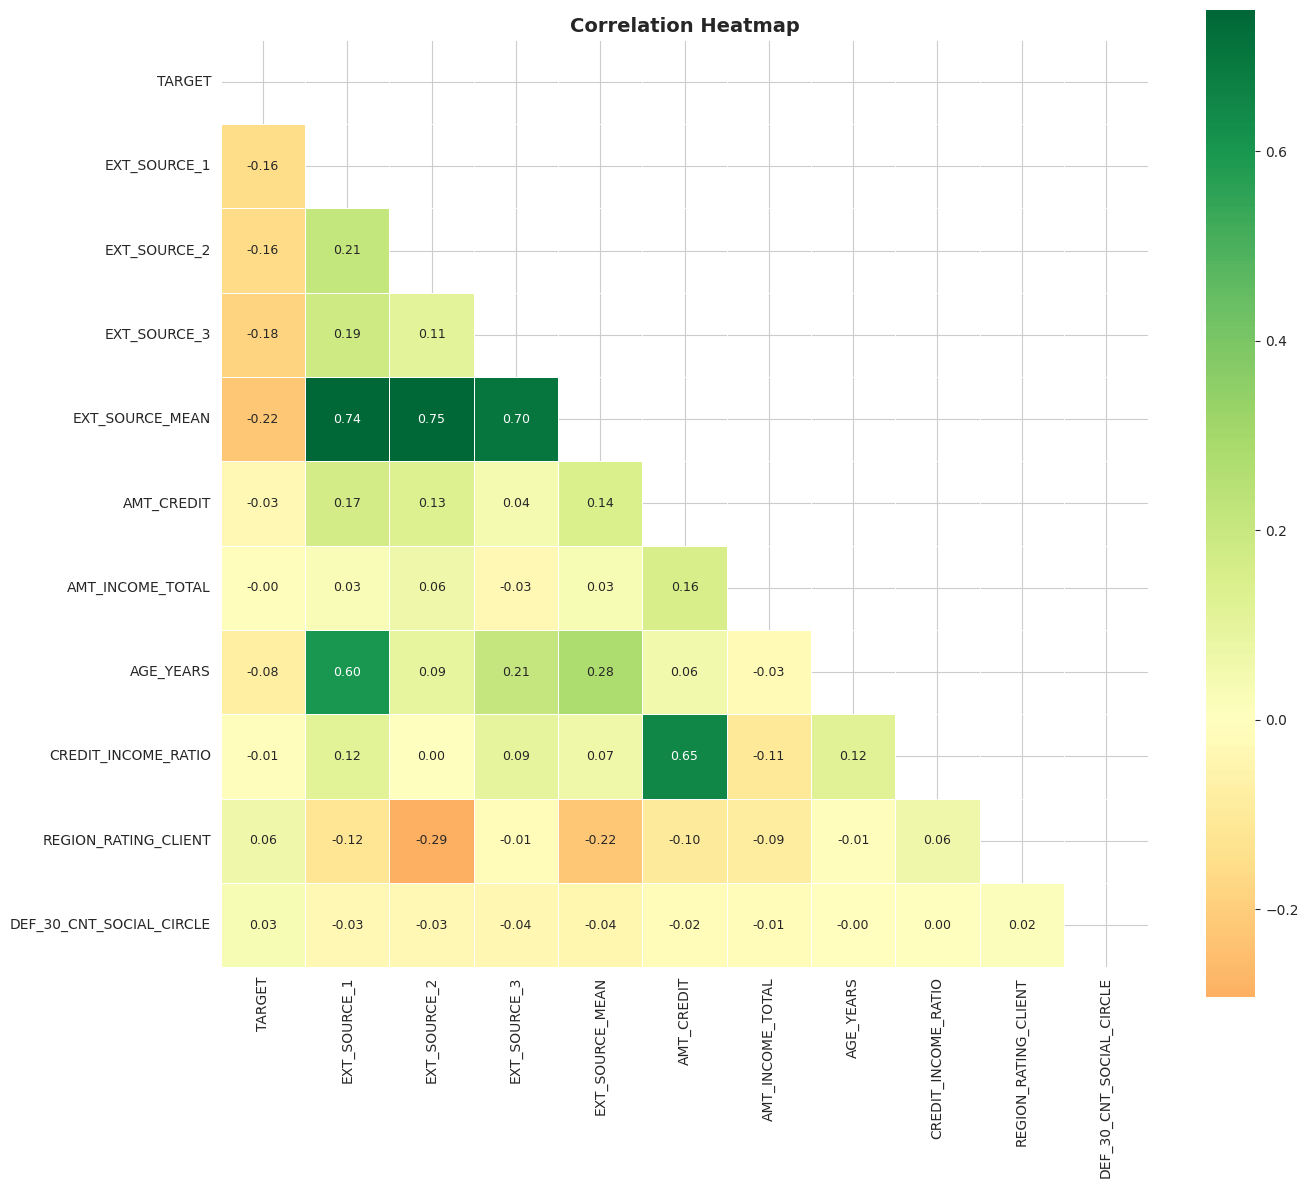

In [ ]:


# Selected important features

selected = ['TARGET','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','EXT_SOURCE_MEAN','AMT_CREDIT','AMT_INCOME_TOTAL','AGE_YEARS',
            'EMPLOYMENT_YEARS','CREDIT_INCOME_RATIO','HAS_COLLATERAL','REGION_RATING_CLIENT','DEF_30_CNT_SOCIAL_CIRCLE']

# Keep only existing columns
selected = [
    c for c in selected
    if c in application_train.columns
    ]

# Create heatmap
plt.figure(figsize=(14,12))
mask = np.triu(np.ones_like(application_train[selected].corr(),dtype=bool))
sns.heatmap(application_train[selected].corr(),
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size':9})
plt.title(
    'Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()


- EXT_SOURCE features exhibit the strongest negative correlation with TARGET,
  confirming their importance in predicting loan repayment behavior.

- AMT_CREDIT,
  AMT_INCOME_TOTAL,
  and CREDIT_INCOME_RATIO show moderate inter-feature relationships,
  while REGION_RATING_CLIENT demonstrates positive association with default risk.




# 10 )  **Final EDA Insights Summary**



In [ ]:
# Target distribution
target_counts = application_train['TARGET'].value_counts()

# Final EDA insights summary
print('=' * 70)
print('FINAL EDA INSIGHTS SUMMARY')
print('=' * 70)
print(f"""

1. CLASS IMBALANCE

   The dataset is highly imbalanced with a recovery ratio
   of nearly {target_counts[0]/target_counts[1]:.1f}:1.

   Most applicants successfully repay loans,
   while default cases represent a much smaller class.

   → Class balancing techniques such as SMOTE,
     undersampling,
     or class weights may be required during model training.

2. EXT_SOURCE FEATURES ARE HIGHLY PREDICTIVE

   EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3
   show the strongest correlation with TARGET.

   The engineered feature EXT_SOURCE_MEAN achieved
   a ROC-AUC score of around 0.71,
   indicating strong predictive capability
   even as a single feature.

3. DAYS_EMPLOYED CONTAINS ANOMALIES

   DAYS_EMPLOYED contains abnormal values (365243),
   which likely represent missing employment records.

   Around 18% of observations contain this anomaly.

   → Anomaly flag creation and NaN replacement
     will be required before modeling.

4. HIGH MISSING VALUE FEATURES

   Several features contain substantial missing values:

   → EXT_SOURCE_1
   → OWN_CAR_AGE
   → COMMONAREA_AVG
   → FLOORSMIN_AVG

   Some columns contain more than 50% missing data.

   → Missing value imputation and missing indicators
     will play an important role during preprocessing.

5. FINANCIAL FEATURES SHOW SKEWNESS AND OUTLIERS

   Features such as:

   → AMT_CREDIT
   → AMT_INCOME_TOTAL
   → AMT_ANNUITY

   contain highly skewed distributions
   along with several extreme outliers.

   → Log transformation,
     robust scaling,
     or outlier capping
     may improve model stability.

6. DEMOGRAPHIC INSIGHTS

   Older applicants generally show lower default rates
   compared to younger borrowers.

   Similarly,
   applicants with longer employment duration
   tend to demonstrate more stable repayment behavior.

7. ASSET OWNERSHIP IMPACT

   Applicants owning property or vehicles
   appear financially more stable
   and generally exhibit better repayment patterns.

   → Collateral-related features may improve
     loan recovery prediction performance.

8. CORRELATION ANALYSIS

   EXT_SOURCE features show the strongest negative correlation
   with TARGET,
   indicating that higher scores are associated
   with lower repayment risk.

   Most individual correlations remain relatively low,
   suggesting that non-linear models such as
   LightGBM,
   XGBoost,
   or CatBoost
   may perform better than simple linear models.
   """)
print('=' * 70)

FINAL EDA INSIGHTS SUMMARY


1. CLASS IMBALANCE

   The dataset is highly imbalanced with a recovery ratio
   of nearly 11.4:1.

   Most applicants successfully repay loans,
   while default cases represent a much smaller class.

   → Class balancing techniques such as SMOTE,
     undersampling,
     or class weights may be required during model training.

2. EXT_SOURCE FEATURES ARE HIGHLY PREDICTIVE

   EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3
   show the strongest correlation with TARGET.

   The engineered feature EXT_SOURCE_MEAN achieved
   a ROC-AUC score of around 0.71,
   indicating strong predictive capability
   even as a single feature.

3. DAYS_EMPLOYED CONTAINS ANOMALIES

   DAYS_EMPLOYED contains abnormal values (365243),
   which likely represent missing employment records.

   Around 18% of observations contain this anomaly.

   → Anomaly flag creation and NaN replacement
     will be required before modeling.

4. HIGH MISSING VALUE FEATURES

   Several features cont